In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, confusion_matrix
from sklearn_extra.cluster import KMedoids
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from scipy.spatial.distance import pdist, squareform, cdist
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

In [3]:
# Đọc dữ liệu
df = pd.read_csv(url, names=columns)
print(f"Kích thước: {df.shape}")

Kích thước: (303, 14)


In [4]:
# Hiển thị 5 dòng đầu tiên của DataFrame
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [7]:
# Kiểm tra giá trị thiếu
all_counts = df.eq('?').sum()
missing_counts = all_counts[all_counts > 0]
print("Số lượng giá trị thiếu ở mỗi cột:")
print(missing_counts)

Số lượng giá trị thiếu ở mỗi cột:
ca      4
thal    2
dtype: int64


In [8]:
# Xóa missing values
df = df.replace('?', np.nan).dropna()
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

In [9]:
df.shape

(297, 14)

In [10]:
X = df.drop('target', axis=1).values
y = df['target'].values
feature_names = list(df.drop('target', axis=1).columns)

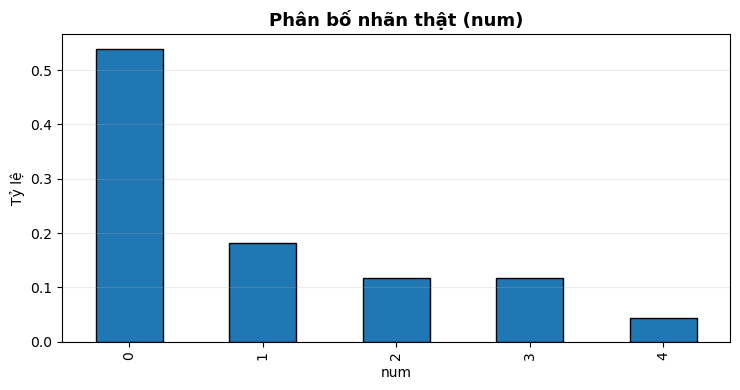

In [11]:
plt.figure(figsize=(7.5,4))
pd.Series(y).value_counts(normalize=True).sort_index().plot(kind="bar", color="#1f77b4", edgecolor="black")
plt.title("Phân bố nhãn thật (num)", fontsize=13, weight="bold")
plt.xlabel("num"); plt.ylabel("Tỷ lệ"); plt.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()

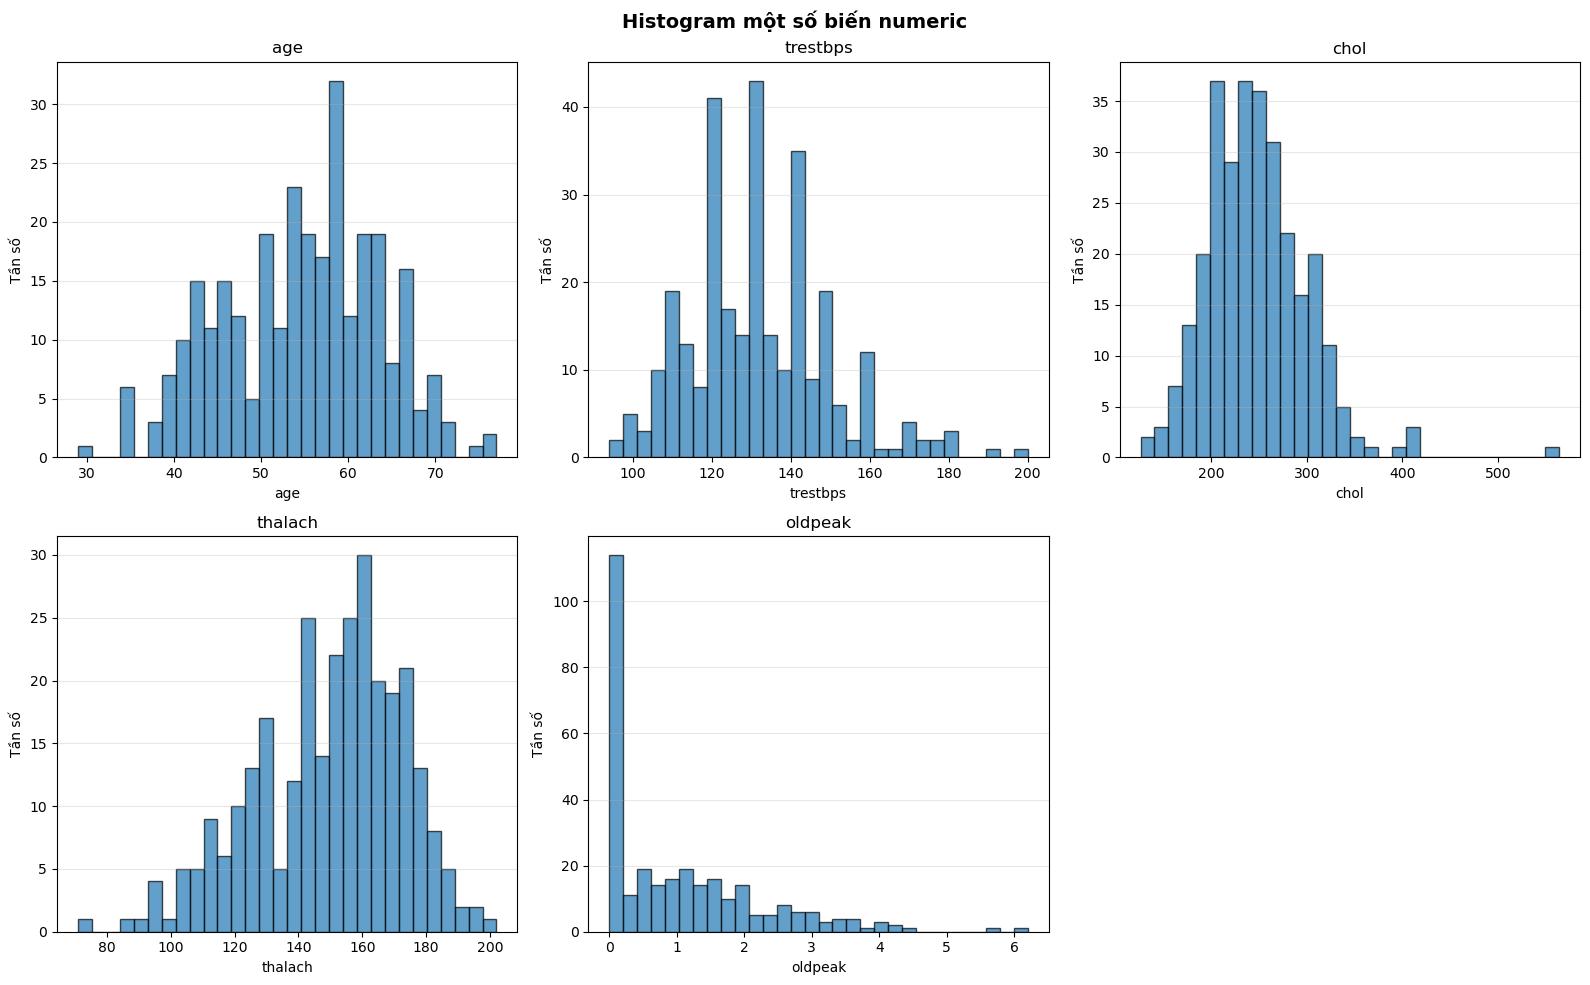

In [12]:
# Vẽ histogram cho một số biến numeric
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feature in zip(axes.ravel(), numeric_cols):
    ax.hist(df[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'{feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Tần số')
    ax.grid(True, alpha=0.3, axis='y')

# Tắt các subplot thừa
for ax in axes.ravel()[len(numeric_cols):]:
    ax.set_visible(False)

plt.suptitle('Histogram một số biến numeric', fontsize=14, fontweight='bold')
plt.tight_layout()


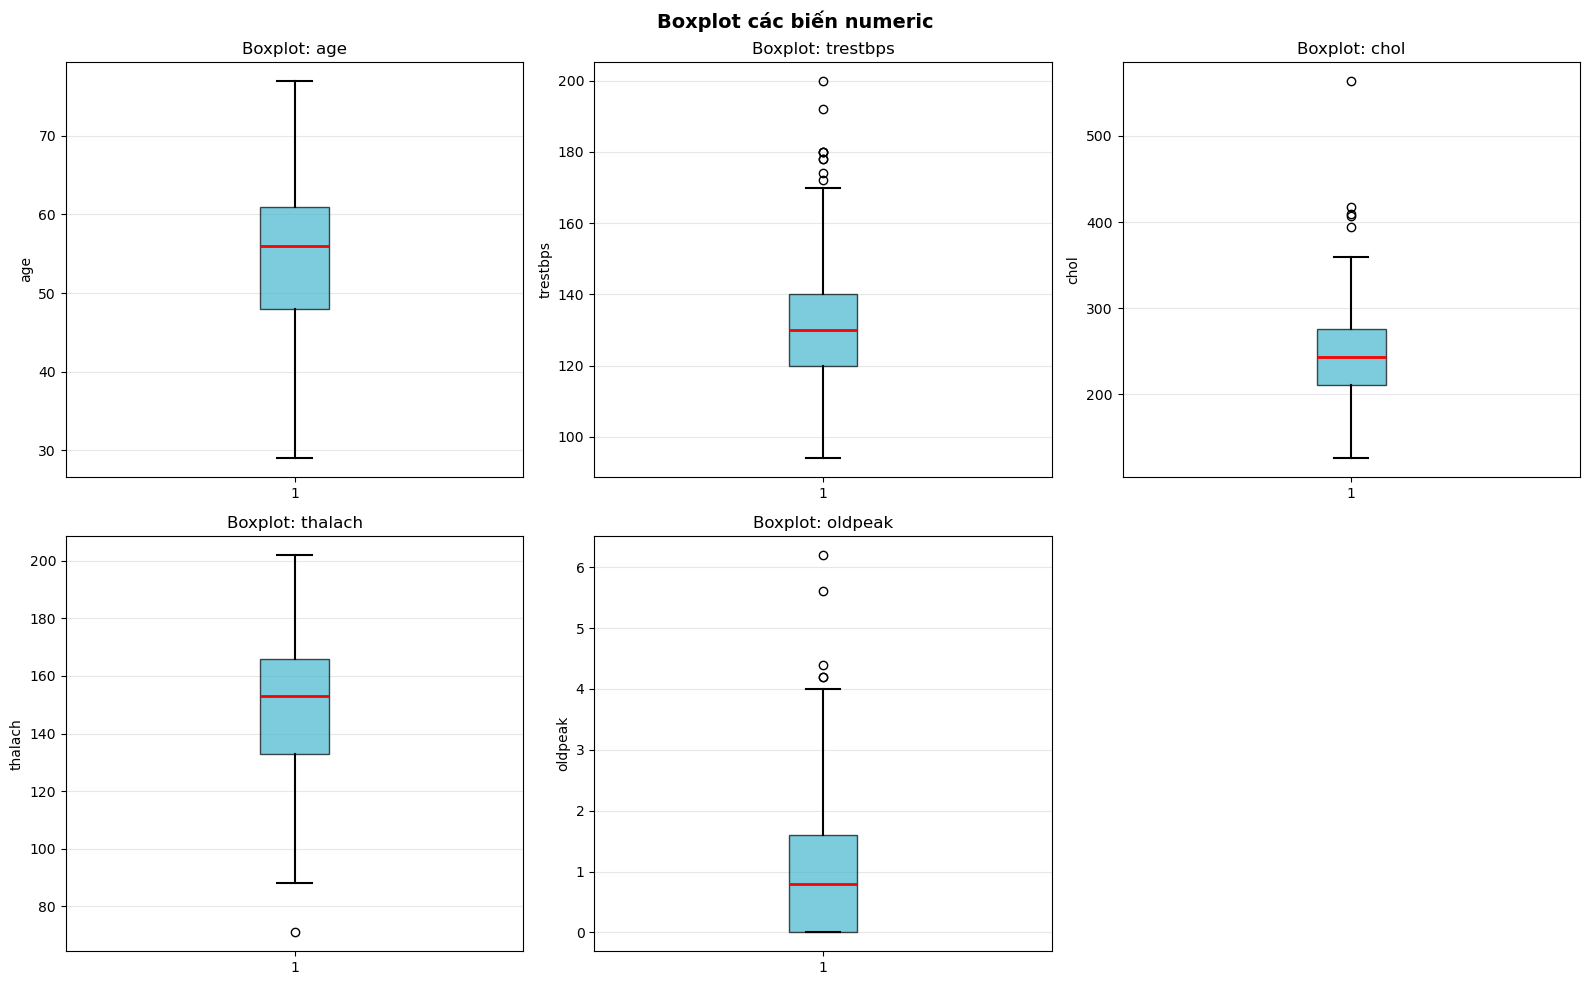

In [13]:
# Vẽ boxplot cho một số biến numeric
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feature in zip(axes.ravel(), numeric_cols):
    ax.boxplot(
        df[feature].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#45B7D1', alpha=0.7),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )
    ax.set_title(f'Boxplot: {feature}')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3, axis='y')

# Ẩn subplot trống
for ax in axes.ravel()[len(numeric_cols):]:
    ax.set_visible(False)

plt.suptitle("Boxplot các biến numeric", fontsize=14, fontweight="bold")
plt.tight_layout()

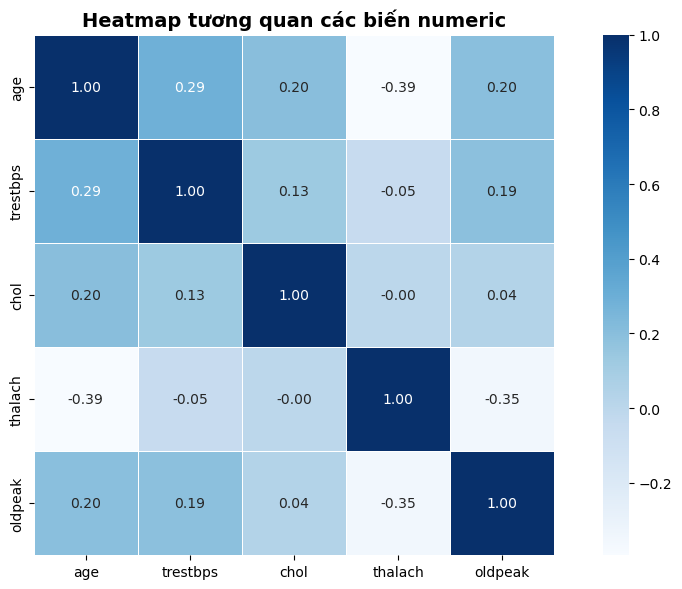

In [14]:
plt.figure(figsize=(10, 6))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="Blues",
    square=True
)

plt.title("Heatmap tương quan các biến numeric", fontsize=14, fontweight='bold')
plt.tight_layout()

In [15]:
# Feature Engineering
# Loại bỏ features có variance thấp
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X)
features_after_var = [feature_names[i] for i in selector_var.get_support(indices=True)]
print(f"Sau loại bỏ low-variance features: {X_var.shape}")
print(f"Features giữ lại: {features_after_var}")

Sau loại bỏ low-variance features: (297, 13)
Features giữ lại: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [16]:
# Feature Selection dùng Mutual Information
selector = SelectKBest(mutual_info_classif, k=min(5, X_var.shape[1]))
X_selected = selector.fit_transform(X_var, y)
selected_idx = selector.get_support(indices=True)
selected_features = [features_after_var[i] for i in selected_idx]
print(f"Top features (Mutual Info): {selected_features}")
print(f"Shape sau feature selection: {X_selected.shape}")

Top features (Mutual Info): ['cp', 'exang', 'oldpeak', 'ca', 'thal']
Shape sau feature selection: (297, 5)


In [17]:
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_selected)
print("Dữ liệu đã chuẩn hóa:")
print(X_scaled[:5])

Dữ liệu đã chuẩn hóa:
[[0.         0.         0.37096774 0.         0.75      ]
 [1.         1.         0.24193548 1.         0.        ]
 [1.         1.         0.41935484 0.66666667 1.        ]
 [0.66666667 0.         0.56451613 0.         0.        ]
 [0.33333333 0.         0.22580645 0.         0.        ]]


In [18]:
# PCA 
# Tính PCA đầy đủ và cumulative variance
pca_full = PCA()
pca_full.fit(X_scaled)
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_opt = np.argmax(cumsum_var >= 0.85) + 1
print(f"Số component tối ưu (85% variance): {n_components_opt}")

Số component tối ưu (85% variance): 3


In [19]:
# Áp dụng PCA với số component tối ưu
pca = PCA(n_components=n_components_opt)
X_pca = pca.fit_transform(X_scaled)
print(f"Shape sau PCA: {X_pca.shape}")
print(f"Variance: {pca.explained_variance_ratio_.sum():.2%}")

Shape sau PCA: (297, 3)
Variance: 85.65%


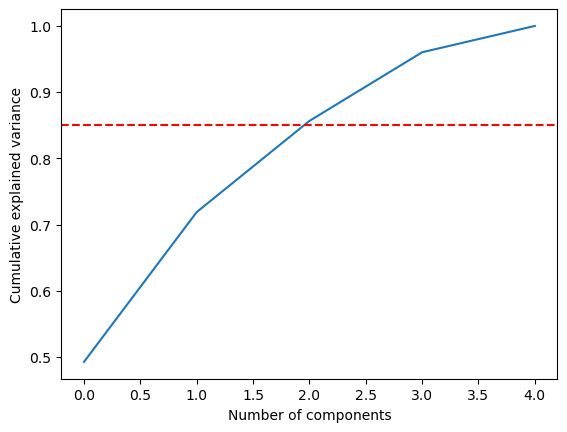

In [20]:
# Vẽ đồ thị cumulative explained variance
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.85, color='r', linestyle='--');


--- Explained Variance Ratio ---
Variance giữ lại với 3 components: 85.65%

Chi tiết từng component:
  PC1: 0.4924 (49.24%)
  PC2: 0.2263 (22.63%)
  PC3: 0.1377 (13.77%)


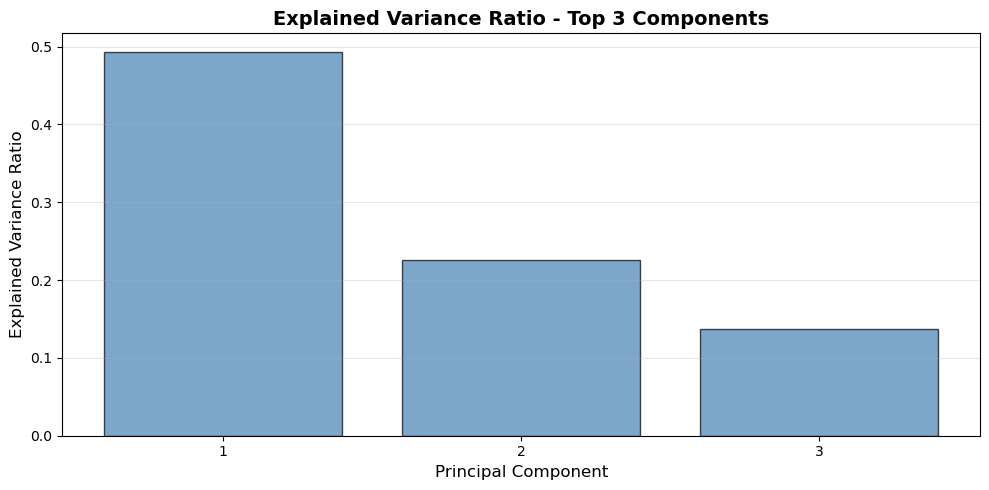

In [21]:
# 2. Explained Variance Ratio - Thường giữ 80-95%
print("\n--- Explained Variance Ratio ---")
print(f"Variance giữ lại với {n_components_opt} components: {cumsum_var[n_components_opt-1]:.2%}")
print(f"\nChi tiết từng component:")
for i in range(min(n_components_opt, len(pca_full.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} ({pca_full.explained_variance_ratio_[i]*100:.2f}%)")

# Vẽ bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(1, n_components_opt + 1), 
        pca_full.explained_variance_ratio_[:n_components_opt], 
        color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title(f'Explained Variance Ratio - Top {n_components_opt} Components', fontsize=14, fontweight='bold')
plt.xticks(range(1, n_components_opt + 1))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()


--- PCA Loadings (Component Weights) ---
Ma trận loadings cho các component:
           PC1    PC2    PC3
cp       0.174  0.062  0.152
exang    0.366  0.279 -0.068
oldpeak  0.085 -0.012  0.029
ca       0.119 -0.052  0.244
thal     0.394 -0.268 -0.084

--- Ý nghĩa từng Principal Component ---

PC1 (giải thích 49.2% variance):
  Top 3 features quan trọng nhất:
    - thal: 0.394 (tăng)
    - exang: 0.366 (tăng)
    - cp: 0.174 (tăng)
  → Có thể đại diện cho: 'Metabolic risk' (nguy cơ chuyển hóa)

PC2 (giải thích 22.6% variance):
  Top 3 features quan trọng nhất:
    - exang: 0.279 (tăng)
    - thal: 0.268 (giảm)
    - cp: 0.062 (tăng)
  → Có thể đại diện cho: 'Lifestyle/Activity' (lối sống/hoạt động)

PC3 (giải thích 13.8% variance):
  Top 3 features quan trọng nhất:
    - ca: 0.244 (tăng)
    - cp: 0.152 (tăng)
    - thal: 0.084 (giảm)


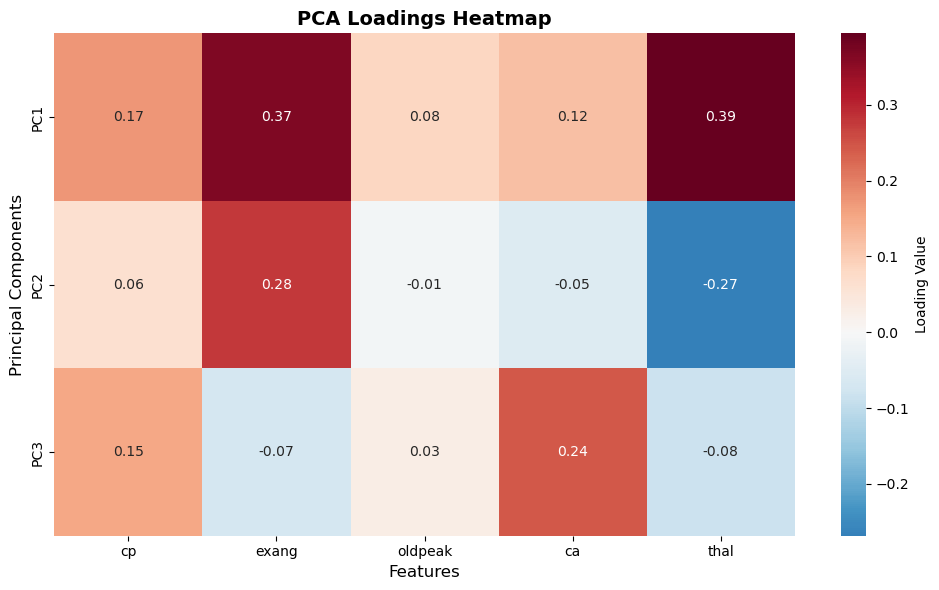

In [22]:
# PCA Loadings (ma trận trọng số) - Giải thích từng component thể hiện yếu tố gì
print("\n--- PCA Loadings (Component Weights) ---")
print("Ma trận loadings cho các component:")

# Lấy loadings (components_) từ PCA
pca_for_loadings = PCA(n_components=n_components_opt)
pca_for_loadings.fit(X_scaled)
loadings = pca_for_loadings.components_.T * np.sqrt(pca_for_loadings.explained_variance_)

# Tạo DataFrame
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(n_components_opt)],
    index=selected_features
)

print(loadings_df.round(3))

# Phân tích ý nghĩa từng PC
print("\n--- Ý nghĩa từng Principal Component ---")
for i in range(n_components_opt):
    pc_name = f"PC{i+1}"
    top_features = loadings_df[pc_name].abs().sort_values(ascending=False).head(3)
    print(f"\n{pc_name} (giải thích {pca_for_loadings.explained_variance_ratio_[i]*100:.1f}% variance):")
    print("  Top 3 features quan trọng nhất:")
    for feat, val in top_features.items():
        direction = "tăng" if loadings_df.loc[feat, pc_name] > 0 else "giảm"
        print(f"    - {feat}: {abs(val):.3f} ({direction})")
    
    # Gợi ý ý nghĩa
    if i == 0:
        print(f"  → Có thể đại diện cho: 'Metabolic risk' (nguy cơ chuyển hóa)")
    elif i == 1:
        print(f"  → Có thể đại diện cho: 'Lifestyle/Activity' (lối sống/hoạt động)")

# Vẽ heatmap loadings
plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading Value'})
plt.title('PCA Loadings Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Principal Components', fontsize=12)
plt.tight_layout()

In [23]:
# K-Medoids from scratch
class KMedoidsScratch:
    """K-Medoids Algorithm - Optimized & Scratch"""
     
     # Khởi tạo tham số
    def __init__(self, n_clusters=3, max_iter=500, tol=1e-4, random_state=None, metric='euclidean'):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.metric = metric

        self.medoids_ = None
        self.medoid_points_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history_ = []
        
        self._rng = np.random.RandomState(random_state) if random_state is not None else np.random.RandomState()

    # Tính ma trận khoảng cách
    def _compute_distance_matrix(self, X):
        """Tính ma trận khoảng cách nhanh với pdist/squareform"""
        if self.metric == 'euclidean':
            D = squareform(pdist(X, metric='euclidean'))
        elif self.metric == 'manhattan':
            D = squareform(pdist(X, metric='cityblock'))
        else:
            D = squareform(pdist(X, metric='euclidean'))
        return D

    # Khởi tạo medoids ngẫu nhiên
    def _init_medoids(self, n_samples):
        """Khởi tạo medoid ngẫu nhiên"""
        return self._rng.choice(n_samples, self.n_clusters, replace=False)

    # Gán nhãn cho mỗi điểm
    def _assign_labels(self, D, medoid_indices):
        """Gán mỗi điểm vào medoid gần nhất"""
        return np.argmin(D[:, medoid_indices], axis=1)

    # Cập nhật medoids
    def _update_medoids(self, D, labels):
        """Cập nhật medoids: chọn điểm có tổng khoảng cách nhỏ nhất trong cụm"""
        new_medoid_indices = np.zeros(self.n_clusters, dtype=int)
        for k in range(self.n_clusters):
            cluster_points = np.where(labels == k)[0]
            if len(cluster_points) == 0:
                new_medoid_indices[k] = self._rng.randint(D.shape[0])
                continue
            total_dist = D[np.ix_(cluster_points, cluster_points)].sum(axis=1)
            new_medoid_indices[k] = cluster_points[np.argmin(total_dist)]
        return new_medoid_indices

    # Cải thiện medoids với thuật toán PAM
    def _update_medoids_pam(self, D, labels, medoid_indices):
        """SWAP phase - cải thiện medoids"""
        n_samples = D.shape[0]
        improved = True
        new_medoids = medoid_indices.copy()
        current_labels = labels.copy()
        best_cost = self._compute_inertia(D, current_labels, new_medoids)

        while improved:
            improved = False
            for i, medoid in enumerate(new_medoids):
                for j in range(n_samples):
                    if j not in new_medoids:
                        temp_medoids = new_medoids.copy()
                        temp_medoids[i] = j
                        temp_labels = self._assign_labels(D, temp_medoids)
                        new_cost = self._compute_inertia(D, temp_labels, temp_medoids)
                        if new_cost < best_cost:
                            best_cost = new_cost
                            new_medoids = temp_medoids
                            current_labels = temp_labels
                            improved = True
                            break
                if improved:
                    break
        labels[:] = current_labels
        return new_medoids

    # Tổng khoảng cách từ điểm đến medoid của nó
    def _compute_inertia(self, D, labels, medoid_indices):
        """Tổng khoảng cách từ điểm đến medoid của nó"""
        return np.sum(D[np.arange(D.shape[0]), medoid_indices[labels]])

    # Huấn luyện mô hình K-Medoids
    def fit(self, X):
        """Huấn luyện mô hình K-Medoids"""
        X = np.asarray(X, dtype=np.float64)
        n_samples = X.shape[0]
        D = self._compute_distance_matrix(X)
        medoid_indices = self._init_medoids(n_samples)
        labels = self._assign_labels(D, medoid_indices)
        inertia = np.inf

        for iteration in range(self.max_iter):
            labels = self._assign_labels(D, medoid_indices)
            new_medoid_indices = self._update_medoids(D, labels)
            labels = self._assign_labels(D, new_medoid_indices)
            new_medoid_indices = self._update_medoids_pam(D, labels, new_medoid_indices)
            new_inertia = self._compute_inertia(D, labels, new_medoid_indices)

            self.history_.append({
                'iteration': iteration,
                'inertia': new_inertia,
                'medoids': new_medoid_indices.copy()
            })

            if np.array_equal(new_medoid_indices, medoid_indices):
                break

            medoid_indices = new_medoid_indices
            inertia = new_inertia
            self.n_iter_ = iteration + 1

        self.medoids_ = medoid_indices
        self.medoid_points_ = X[medoid_indices]
        self.labels_ = labels
        self.inertia_ = inertia
        return self

    # Dự đoán cụm cho dữ liệu mới
    def predict(self, X):
        """Dự đoán cụm cho dữ liệu mới"""
        if self.medoid_points_ is None:
            raise ValueError("Phải fit() trước")
        X = np.asarray(X, dtype=np.float64)
        D = cdist(X, self.medoid_points_, metric=self.metric)
        return np.argmin(D, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

In [24]:
# Tìm k tối ưu dùng X_pca
inertias_elbow = []
silhouette_scores_elbow = []
K_range = range(2, 11)

for k in K_range:
    print(f"Thử k={k}...", end=" ")
    
    km = KMedoidsScratch(n_clusters=k, max_iter=500, random_state=42)
    labels_k = km.fit_predict(X_pca)
    
    inertias_elbow.append(km.inertia_)
    sil_k = silhouette_score(X_pca, labels_k)  
    silhouette_scores_elbow.append(sil_k)
    
    print(f"Inertia={km.inertia_:.4f}, Silhouette={sil_k:.4f}")

best_k_sil = K_range[np.argmax(silhouette_scores_elbow)]
print("K tối ưu theo silhouette:", best_k_sil)

Thử k=2... Inertia=143.9200, Silhouette=0.4378
Thử k=3... Inertia=101.1384, Silhouette=0.5565
Thử k=4... Inertia=78.7022, Silhouette=0.6446
Thử k=5... Inertia=69.8651, Silhouette=0.6249
Thử k=6... Inertia=61.1625, Silhouette=0.5537
Thử k=7... Inertia=54.3504, Silhouette=0.5153
Thử k=8... Inertia=48.0588, Silhouette=0.5065
Thử k=9... Inertia=41.7596, Silhouette=0.5256
Thử k=10... Inertia=37.6881, Silhouette=0.5421
K tối ưu theo silhouette: 4


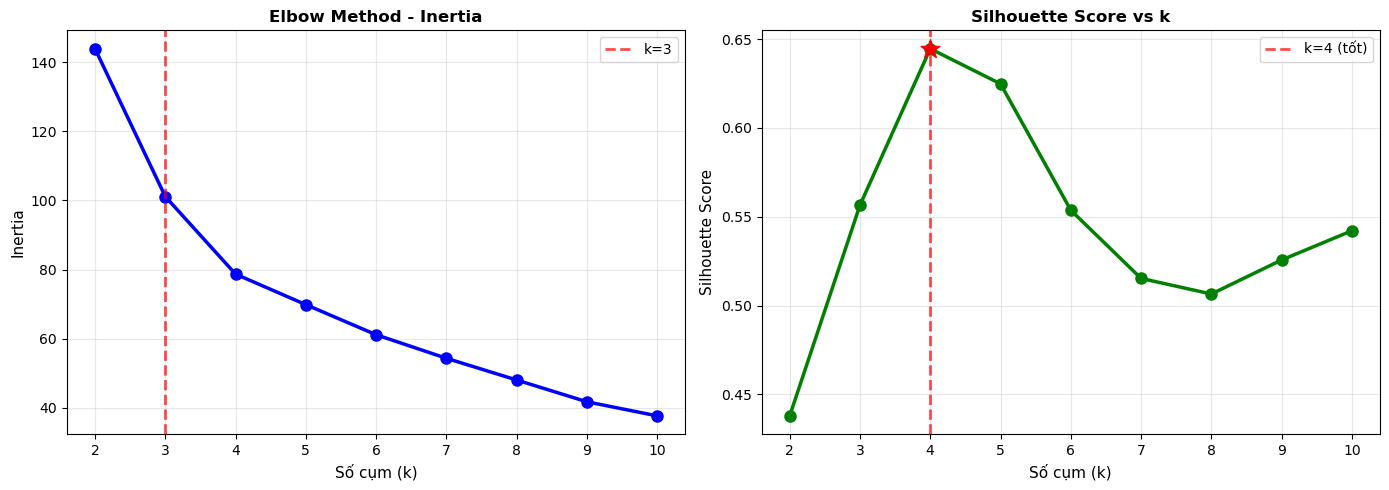

In [25]:
#  Vẽ đồ thị Elbow và Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias_elbow, 'bo-', linewidth=2.5, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, alpha=0.7, label='k=3')
axes[0].set_title('Elbow Method - Inertia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số cụm (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_xticks(K_range)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

axes[1].plot(K_range, silhouette_scores_elbow, 'go-', linewidth=2.5, markersize=8)
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'k={best_k_sil} (tốt)')
axes[1].scatter([best_k_sil], [max(silhouette_scores_elbow)], color='red', s=200, marker='*', zorder=5)
axes[1].set_title('Silhouette Score vs k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số cụm (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_xticks(K_range)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()

In [26]:
# Khởi tạo K-Medoids tự cài đặt
kmedoids_scratch = KMedoidsScratch(n_clusters=best_k_sil, max_iter=500, random_state=42)

# Khởi tạo K-Medoids sklearn
kmedoids_sklearn = KMedoids(n_clusters=4, init='k-medoids++', 
                                   random_state=42, max_iter=500)

In [27]:
# Huấn luyện K-Medoids tự cài đặt
labels_scratch = kmedoids_scratch.fit_predict(X_pca)
print(f"Số vòng lặp: {kmedoids_scratch.n_iter_}")
print(f"Inertia: {kmedoids_scratch.inertia_:.4f}")
print(f"Medoids indices: {kmedoids_scratch.medoids_}")

Số vòng lặp: 1
Inertia: 78.7022
Medoids indices: [106 152  46 194]


In [28]:
# Huấn luyện K-Medoids sklearn
labels_sklearn = kmedoids_sklearn.fit_predict(X_pca)
print(f"Số vòng lặp: {kmedoids_sklearn.n_iter_}")
print(f"Inertia: {kmedoids_sklearn.inertia_:.4f}")
print(f"Medoids indices: {kmedoids_sklearn.medoid_indices_}")

Số vòng lặp: 1
Inertia: 78.7022
Medoids indices: [ 46 106 152 194]


In [29]:
# Đánh giá mô hình
sil_scratch = silhouette_score(X_pca, labels_scratch)
db_scratch = davies_bouldin_score(X_pca, labels_scratch)
ch_scratch = calinski_harabasz_score(X_pca, labels_scratch)

sil_sklearn = silhouette_score(X_pca, labels_sklearn)
db_sklearn = davies_bouldin_score(X_pca, labels_sklearn)
ch_sklearn = calinski_harabasz_score(X_pca, labels_sklearn)

comparison_data = {
    'Chỉ Số': ['Silhouette Score', 'Davies-Bouldin Score', 'Calinski-Harabasz Score', 'Inertia'],
    'K-Medoids Scratch': [f'{sil_scratch:.4f}', f'{db_scratch:.4f}', f'{ch_scratch:.2f}', f'{kmedoids_scratch.inertia_:.4f}'],
    'K-Medoids Sklearn': [f'{sil_sklearn:.4f}', f'{db_sklearn:.4f}', f'{ch_sklearn:.2f}', f'{kmedoids_sklearn.inertia_:.4f}']
}

df_comparison = pd.DataFrame(comparison_data)
print("Bảng so sánh các chỉ số:")
print(df_comparison.to_string(index=False))


Bảng so sánh các chỉ số:
                 Chỉ Số K-Medoids Scratch K-Medoids Sklearn
       Silhouette Score            0.6446            0.6446
   Davies-Bouldin Score            0.6033            0.6033
Calinski-Harabasz Score            416.94            416.94
                Inertia           78.7022           78.7022


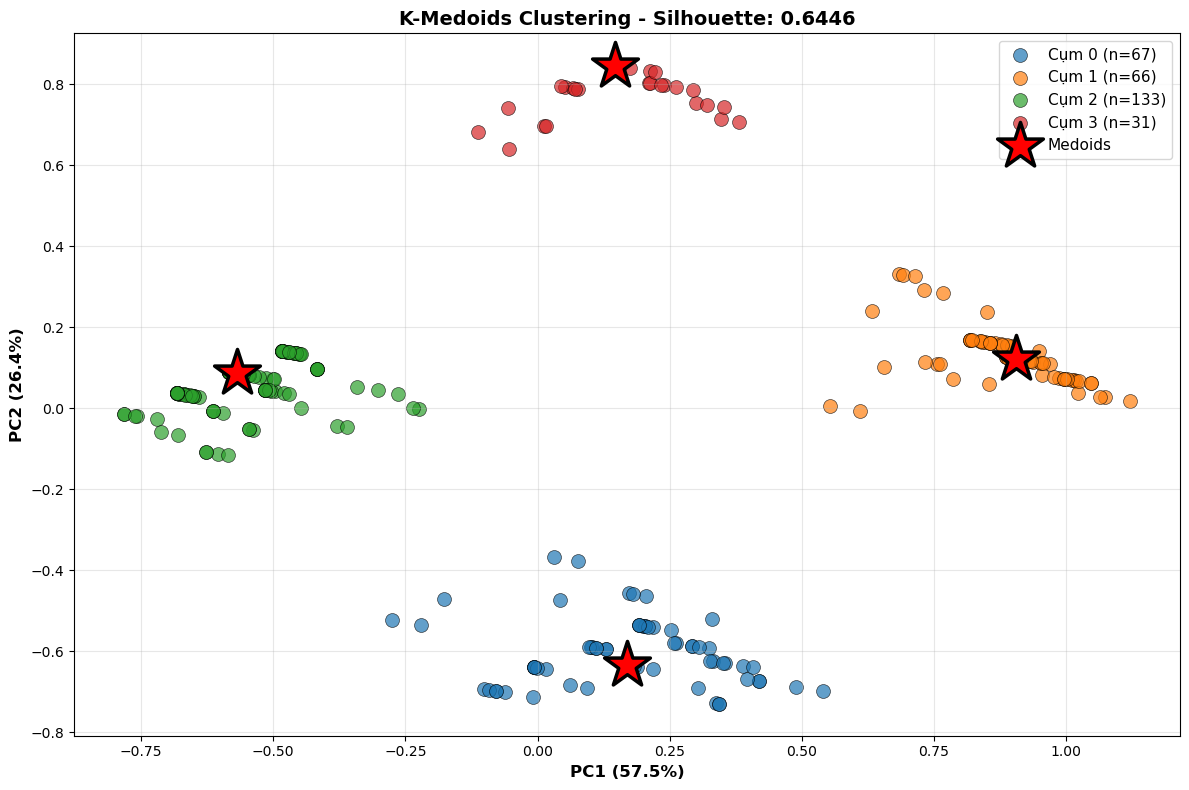

In [30]:
# Vẽ Scatter plot K-Medoids tự cài đặt
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_pca)
medoids_pca_viz = X_pca_viz[kmedoids_scratch.medoids_]

plt.figure(figsize=(12, 8))
colors = plt.get_cmap('tab10').colors

for i in range(best_k_sil):
    mask = labels_scratch == i
    plt.scatter(X_pca_viz[mask,0], X_pca_viz[mask,1], 
                c=[colors[i % len(colors)]], alpha=0.7, s=100, 
                edgecolors='black', linewidth=0.5,
                label=f'Cụm {i} (n={np.sum(mask)})')

# Vẽ medoids
plt.scatter(medoids_pca_viz[:,0], medoids_pca_viz[:,1], 
            c='red', marker='*', s=1200, edgecolors='black', linewidths=2.5, label='Medoids', zorder=5)

# Nhãn trục với tỉ lệ variance 2D
var_ratio = np.round(pca_viz.explained_variance_ratio_ * 100, 1)
plt.xlabel(f'PC1 ({var_ratio[0]}%)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({var_ratio[1]}%)', fontsize=12, fontweight='bold')
plt.title(f'K-Medoids Clustering - Silhouette: {sil_scratch:.4f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()

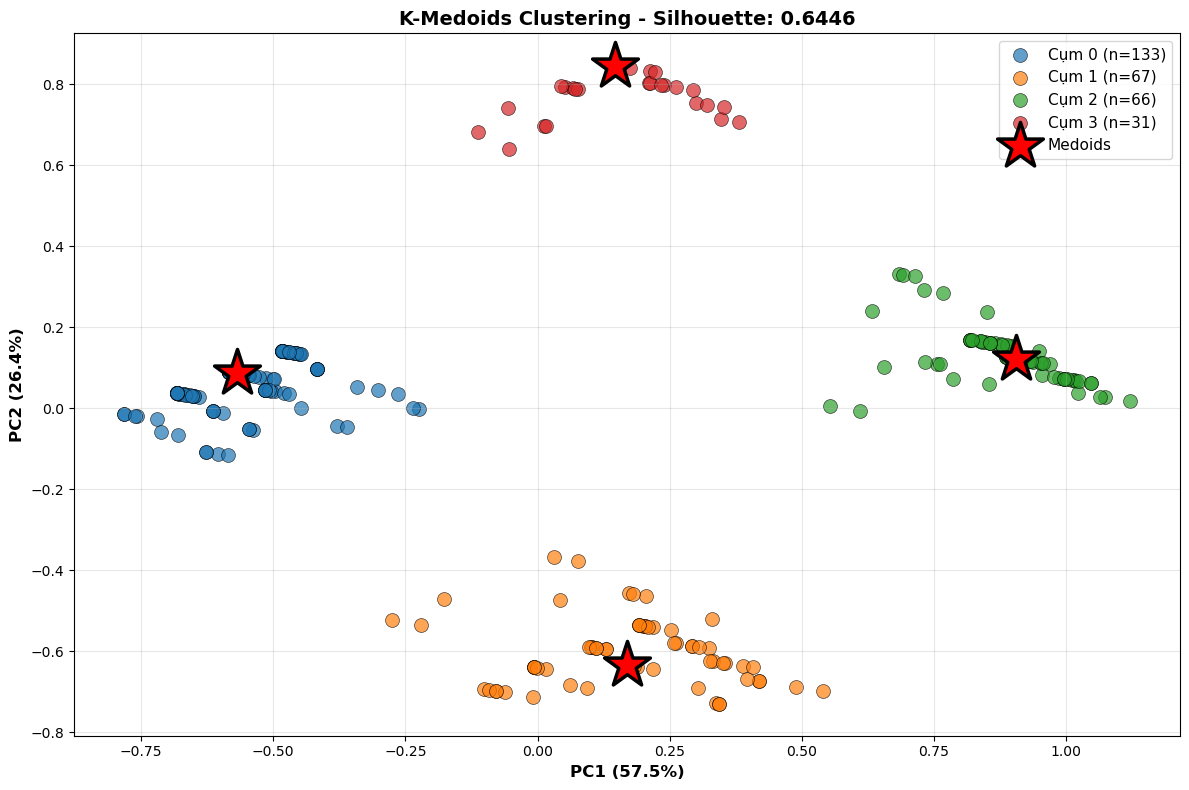

In [31]:
# Vẽ Scatter plot K-Medoids sklearn
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_pca)
medoids_pca_viz = X_pca_viz[kmedoids_sklearn.medoid_indices_]

plt.figure(figsize=(12, 8))
colors = plt.get_cmap('tab10').colors

for i in range(best_k_sil):
    mask = labels_sklearn == i
    plt.scatter(X_pca_viz[mask,0], X_pca_viz[mask,1], 
                c=[colors[i % len(colors)]], alpha=0.7, s=100, 
                edgecolors='black', linewidth=0.5,
                label=f'Cụm {i} (n={np.sum(mask)})')

# Vẽ medoids
plt.scatter(medoids_pca_viz[:,0], medoids_pca_viz[:,1], 
            c='red', marker='*', s=1200, edgecolors='black', linewidths=2.5, label='Medoids', zorder=5)

# Nhãn trục với tỉ lệ variance 2D
var_ratio = np.round(pca_viz.explained_variance_ratio_ * 100, 1)
plt.xlabel(f'PC1 ({var_ratio[0]}%)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({var_ratio[1]}%)', fontsize=12, fontweight='bold')
plt.title(f'K-Medoids Clustering - Silhouette: {sil_sklearn:.4f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()

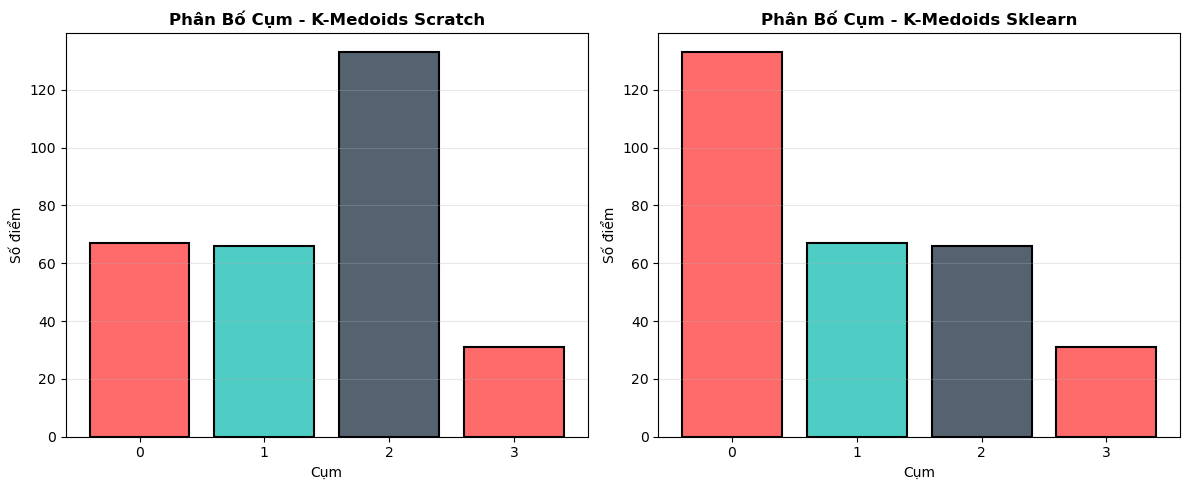

In [32]:
# Vẽ phân bố cụm
# Màu cho từng cụm
colors = ['#FF6B6B', '#4ECDC4', '#556270']

# Tạo 1 hàng, 2 cột subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))  # axes là mảng 1D

# --- Phân bố cụm Scratch ---
cluster_counts_scratch = [np.sum(labels_scratch == k) for k in range(4)]
axes[0].bar(range(4), cluster_counts_scratch, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Phân Bố Cụm - K-Medoids Scratch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cụm')
axes[0].set_ylabel('Số điểm')
axes[0].set_xticks(range(4))
axes[0].grid(True, alpha=0.3, axis='y')

# --- Phân bố cụm Sklearn ---
cluster_counts_sklearn = [np.sum(labels_sklearn == k) for k in range(4)]
axes[1].bar(range(4), cluster_counts_sklearn, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title('Phân Bố Cụm - K-Medoids Sklearn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cụm')
axes[1].set_ylabel('Số điểm')
axes[1].set_xticks(range(4))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

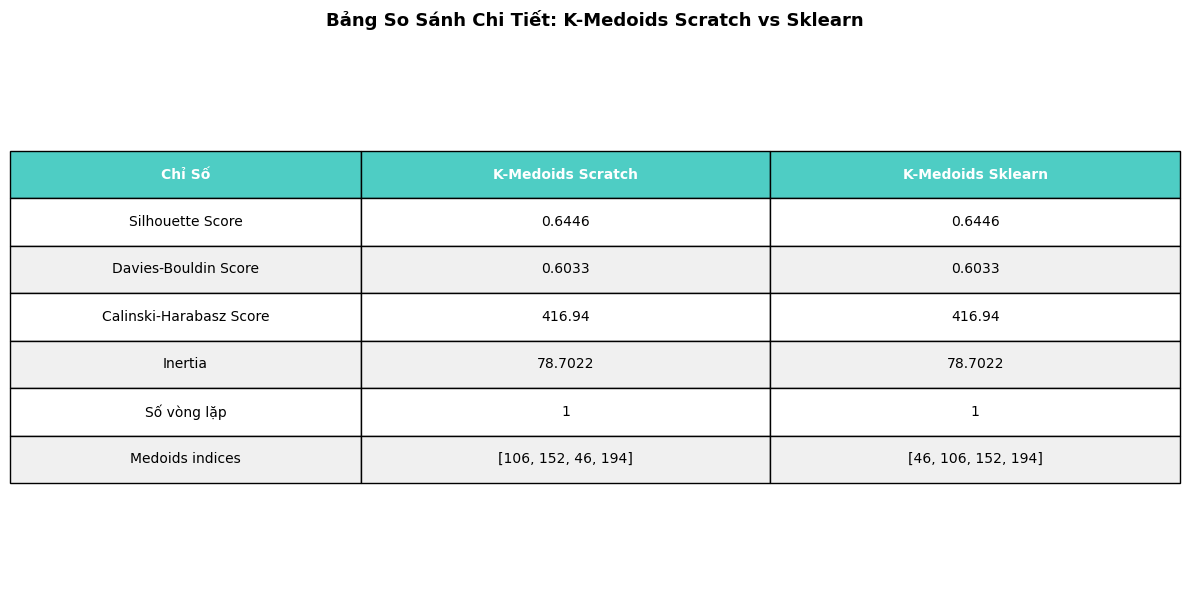

In [33]:
# Tạo bảng so sánh chi tiết
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# Tạo dữ liệu bảng
table_data = [
    ['Chỉ Số', 'K-Medoids Scratch', 'K-Medoids Sklearn'],
    ['Silhouette Score', f'{sil_scratch:.4f}', f'{sil_sklearn:.4f}'],
    ['Davies-Bouldin Score', f'{db_scratch:.4f}', f'{db_sklearn:.4f}'],
    ['Calinski-Harabasz Score', f'{ch_scratch:.2f}', f'{ch_sklearn:.2f}'],
    ['Inertia', f'{kmedoids_scratch.inertia_:.4f}', f'{kmedoids_sklearn.inertia_:.4f}'],
    ['Số vòng lặp', f'{kmedoids_scratch.n_iter_}', f'{kmedoids_sklearn.n_iter_}'],
    ['Medoids indices', str(list(kmedoids_scratch.medoids_)), str(list(kmedoids_sklearn.medoid_indices_))]
]

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Định dạng header
for i in range(3):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Định dạng các hàng
for i in range(1, len(table_data)):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F0F0F0')

plt.title('Bảng So Sánh Chi Tiết: K-Medoids Scratch vs Sklearn', 
         fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()

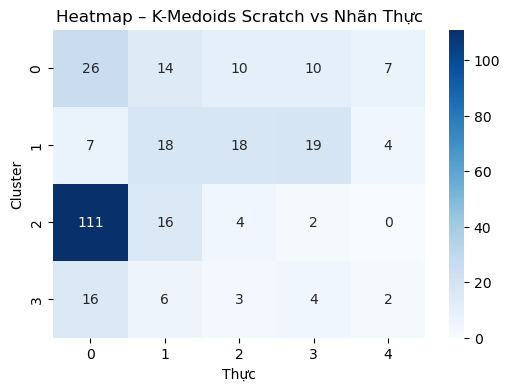

In [47]:
# Tạo heatmap so sánh nhãn cụm và nhãn thực cho K-Medoids Scratch
ct_scratch = pd.crosstab(labels_scratch, y, rownames=['Cluster'], colnames=['Thực'])
plt.figure(figsize=(6,4))
sns.heatmap(ct_scratch, annot=True, fmt='d', cmap='Blues')
plt.title("Heatmap – K-Medoids Scratch vs Nhãn Thực");

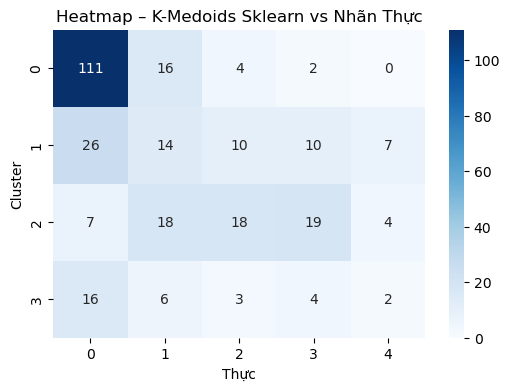

In [48]:
# Tạo heatmap so sánh nhãn cụm và nhãn thực cho K-Medoids Sklearn
ct_sklearn = pd.crosstab(labels_sklearn, y, rownames=['Cluster'], colnames=['Thực'])
plt.figure(figsize=(6,4))   
sns.heatmap(ct_sklearn, annot=True, fmt='d', cmap='Blues')
plt.title("Heatmap – K-Medoids Sklearn vs Nhãn Thực");

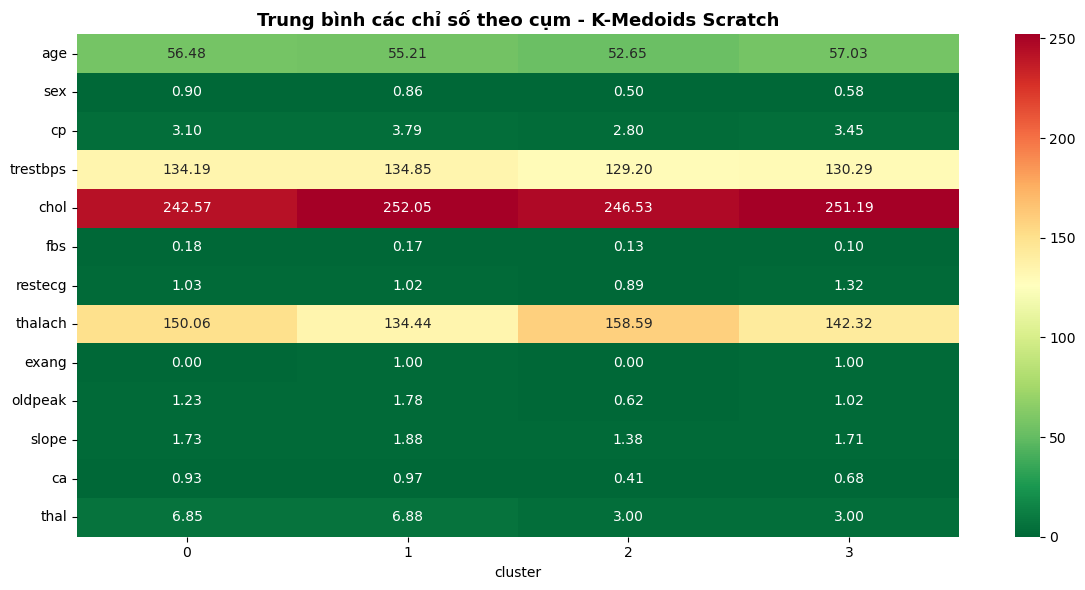

In [39]:
# Tạo bảng trung bình các features theo cụm - K-Medoids Scratch
df_prof_scratch = df.drop(columns=['target'], errors='ignore').copy()
df_prof_scratch['cluster'] = labels_scratch
df_prof_scratch['target'] = y

num_cols_prof = df_prof_scratch.select_dtypes(include=[np.number]).columns.drop(['cluster', 'target'], errors='ignore')
profile_scratch = df_prof_scratch.groupby('cluster')[num_cols_prof].mean().round(2)

plt.figure(figsize=(12, max(6, 0.35*len(num_cols_prof))))
sns.heatmap(profile_scratch.T, cmap='RdYlGn_r', annot=True, fmt='.2f')
plt.title('Trung bình các chỉ số theo cụm - K-Medoids Scratch', fontsize=13, weight='bold')
plt.tight_layout()

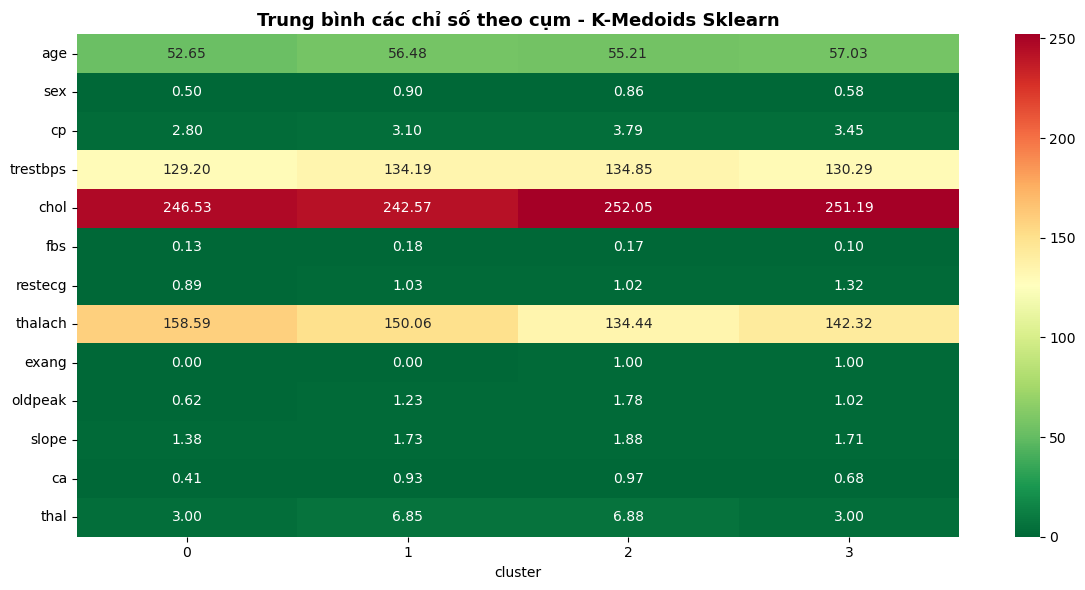

In [ ]:
# Tạo bảng trung bình các features theo cụm - K-Medoids Sklearn
df_prof_sklearn = df.drop(columns=['target'], errors='ignore').copy()
df_prof_sklearn['cluster'] = labels_sklearn
df_prof_sklearn['target'] = y

num_cols_prof_sklearn = df_prof_sklearn.select_dtypes(include=[np.number]).columns.drop(['cluster', 'target'], errors='ignore')
profile_sklearn = df_prof_sklearn.groupby('cluster')[num_cols_prof_sklearn].mean().round(2)

plt.figure(figsize=(12, max(6, 0.35*len(num_cols_prof_sklearn))))
sns.heatmap(profile_sklearn.T, cmap='RdYlGn_r', annot=True, fmt='.2f')
plt.title('Trung bình các chỉ số theo cụm - K-Medoids Sklearn', fontsize=13, weight='bold')
plt.tight_layout()

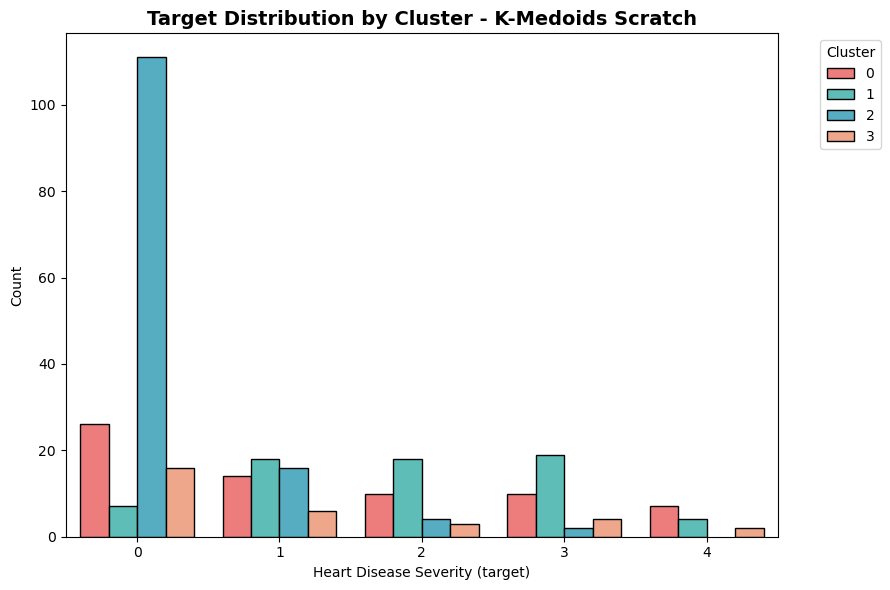

In [42]:
# Phân bố Target theo Cluster - K-Medoids Scratch
palette_scratch = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
plt.figure(figsize=(9,6))
sns.countplot(x=pd.Series(y, name="target"), hue=pd.Series(labels_scratch, name="cluster"),
              palette=palette_scratch, edgecolor="black")
plt.title("Target Distribution by Cluster - K-Medoids Scratch", fontsize=14, weight="bold")
plt.xlabel("Heart Disease Severity (target)"); plt.ylabel("Count")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

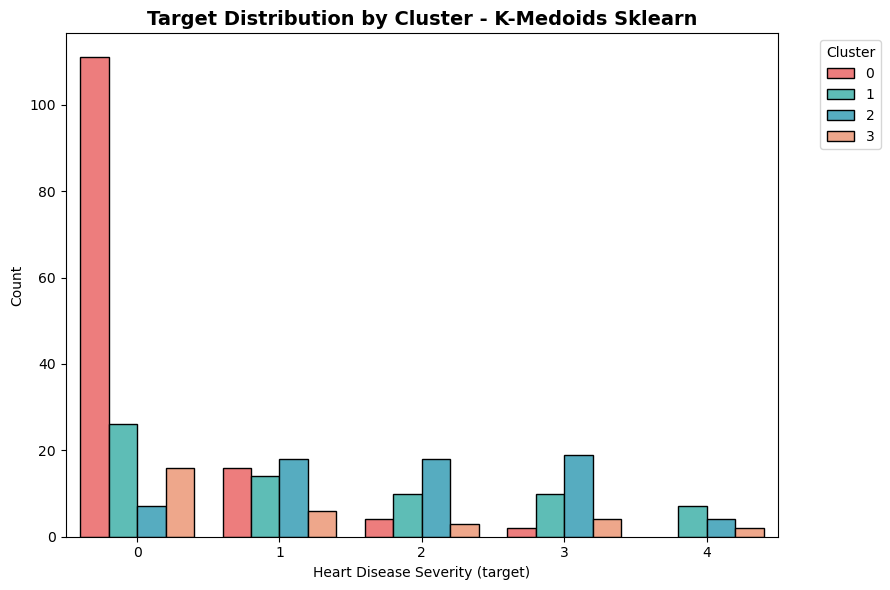

In [43]:
# Phân bố Target theo Cluster - K-Medoids Sklearn
palette_sklearn = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
plt.figure(figsize=(9,6))
sns.countplot(x=pd.Series(y, name="target"), hue=pd.Series(labels_sklearn, name="cluster"),
              palette=palette_sklearn, edgecolor="black")
plt.title("Target Distribution by Cluster - K-Medoids Sklearn", fontsize=14, weight="bold")
plt.xlabel("Heart Disease Severity (target)"); plt.ylabel("Count")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

In [36]:
# Định nghĩa hàm purity score
def purity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return np.sum(np.max(cm, axis=1)) / np.sum(cm)


--- Risk Level Summary (K-Medoids Scratch) ---
 Cluster  Size  Purity (%)  Mean_target Risk_Tier
       2   133        83.5         0.23   Healthy
       3    31        51.6         1.03      Mild
       0    67        38.8         1.37      Mild
       1    66        28.8         1.92  Moderate


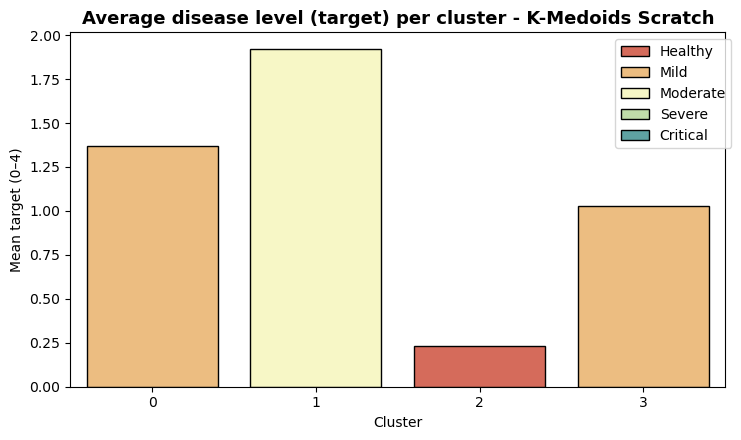

In [45]:
# Risk level summary - K-Medoids Scratch
cluster_size_scratch = df_prof_scratch.groupby("cluster").size()
mean_target_scratch = df_prof_scratch.groupby("cluster")["target"].mean().round(2)
purity_per_cluster_scratch = (pd.crosstab(df_prof_scratch["cluster"], df_prof_scratch["target"]).max(axis=1) / cluster_size_scratch) * 100
risk_tbl_scratch = pd.DataFrame({"Cluster":cluster_size_scratch.index, "Size":cluster_size_scratch.values,
                         "Purity (%)":purity_per_cluster_scratch.values.round(1), "Mean_target":mean_target_scratch.values})
risk_tbl_scratch["Risk_Tier"] = pd.cut(risk_tbl_scratch["Mean_target"], bins=[-1,0.5,1.5,2.5,3.5,10],
                               labels=["Healthy","Mild","Moderate","Severe","Critical"])

print("\n--- Risk Level Summary (K-Medoids Scratch) ---")
print(risk_tbl_scratch.sort_values("Mean_target").to_string(index=False))

plt.figure(figsize=(7.5,4.5))
sns.barplot(data=risk_tbl_scratch.sort_values("Mean_target"), x="Cluster", y="Mean_target",
            hue="Risk_Tier", dodge=False, palette="Spectral", edgecolor="black")
plt.title("Average disease level (target) per cluster - K-Medoids Scratch", fontsize=13, weight="bold")
plt.ylabel("Mean target (0–4)"); plt.xlabel("Cluster")
plt.legend(bbox_to_anchor=(1.02,1.0)); plt.tight_layout(); plt.show()

In [37]:
# Tính purity score cho K-Medoids Scratch
purity = purity_score(y, labels_scratch)
print("Purity Score (K-Medoids Scratch):", round(purity, 4))

Purity Score (K-Medoids Scratch): 0.5825



--- Risk Level Summary (K-Medoids Sklearn) ---
 Cluster  Size  Purity (%)  Mean_target Risk_Tier
       0   133        83.5         0.23   Healthy
       3    31        51.6         1.03      Mild
       1    67        38.8         1.37      Mild
       2    66        28.8         1.92  Moderate


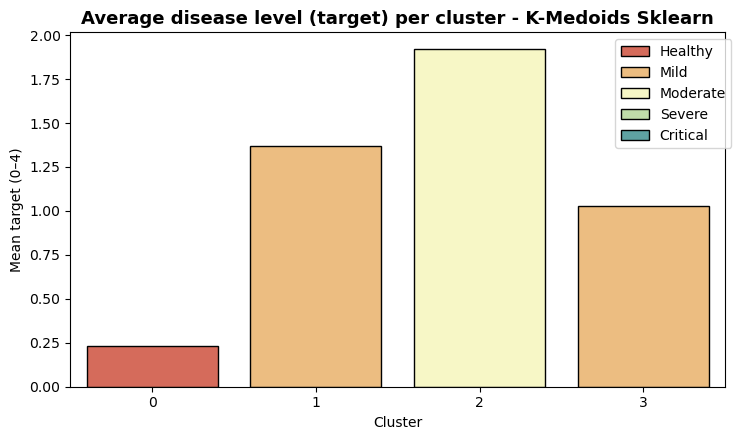

In [46]:
# Risk level summary - K-Medoids Sklearn
cluster_size_sklearn = df_prof_sklearn.groupby("cluster").size()
mean_target_sklearn = df_prof_sklearn.groupby("cluster")["target"].mean().round(2)
purity_per_cluster_sklearn = (pd.crosstab(df_prof_sklearn["cluster"], df_prof_sklearn["target"]).max(axis=1) / cluster_size_sklearn) * 100
risk_tbl_sklearn = pd.DataFrame({"Cluster":cluster_size_sklearn.index, "Size":cluster_size_sklearn.values,
                         "Purity (%)":purity_per_cluster_sklearn.values.round(1), "Mean_target":mean_target_sklearn.values})
risk_tbl_sklearn["Risk_Tier"] = pd.cut(risk_tbl_sklearn["Mean_target"], bins=[-1,0.5,1.5,2.5,3.5,10],
                               labels=["Healthy","Mild","Moderate","Severe","Critical"])

print("\n--- Risk Level Summary (K-Medoids Sklearn) ---")
print(risk_tbl_sklearn.sort_values("Mean_target").to_string(index=False))

plt.figure(figsize=(7.5,4.5))
sns.barplot(data=risk_tbl_sklearn.sort_values("Mean_target"), x="Cluster", y="Mean_target",
            hue="Risk_Tier", dodge=False, palette="Spectral", edgecolor="black")
plt.title("Average disease level (target) per cluster - K-Medoids Sklearn", fontsize=13, weight="bold")
plt.ylabel("Mean target (0–4)"); plt.xlabel("Cluster")
plt.legend(bbox_to_anchor=(1.02,1.0)); plt.tight_layout(); plt.show()

In [38]:
# Tính purity score cho K-Medoids Sklearn
purity_sklearn = purity_score(y, labels_sklearn)
print("Purity Score (K-Medoids Sklearn):", round(purity_sklearn, 4))

Purity Score (K-Medoids Sklearn): 0.5825
